In [75]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from feynman import Diagram
from feynman import Line

class Theme:
    theme = "light"
    @staticmethod
    def set(_theme):
        Theme.theme = _theme
        if(Theme.theme == "dark"):
            plt.style.use('dark_background')
        else:
            plt.style.use('default')
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['cmr10']  # Основной шрифт для текста
        plt.rcParams['mathtext.fontset'] = 'cm'
    @staticmethod
    def color():
        if(Theme.theme == "light"):
            return "black"
        else:
            return "white"
    @staticmethod
    def back():
        if(Theme.theme == "light"):
            return "white"
        else:
            return "black"
    @staticmethod
    def suff():
        if(Theme.theme == "light"):
            return "l"
        else:
            return "d"

## Unitary triangle

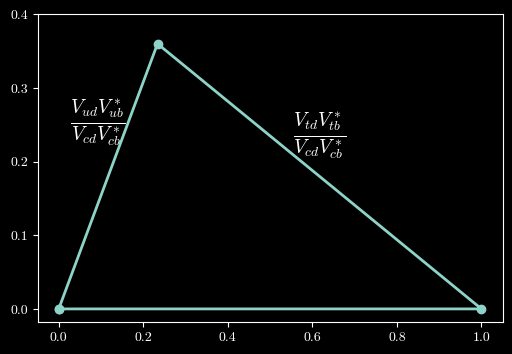

In [ ]:
import numpy as np
Theme.set("dark")

Vud, Vus, Vub = 0.974, 0.227, 0.004 * np.exp(-1j * np.deg2rad(57))
Vcd, Vcs, Vcb = 0.227, 0.973, 0.04
Vtd, Vts, Vtb = 0.008 * np.exp(-1j * np.deg2rad(57)), 0.04, 0.999

A = Vud * np.conj(Vub) / (Vcd * np.conj(Vcb))
B = 1  # единичный вектор (середина)
C = Vtd * np.conj(Vtb) / (Vcd * np.conj(Vcb))

z0 = 0
z1 = B
z2 = A

triangle = np.array([z0, z1, z2, z0])


plt.figure(figsize=(6,4))

plt.plot(triangle.real, triangle.imag, '-o', lw=2)

Ztext = 0.75*z2+0.38*z1
plt.text(Ztext.real, Ztext.imag, '$\\frac{V_{td}V_{tb}^*}{V_{cd}V_{cb}^*}$', fontsize=20, ha='left', va='top')
Ztext1 = 0.8*z2-0.16
plt.text(Ztext1.real, Ztext1.imag, '$\\frac{V_{ud}V_{ub}^*}{V_{cd}V_{cb}^*}$', fontsize=20, ha='left', va='top')

plt.yticks([0,0.1,0.2,0.3,0.4])
plt.axis()
plt.savefig('../docs/KaonDecay/CKM/images/unitary-triangle-d.svg',transparent=True)
plt.show()



## Diagramm n->p

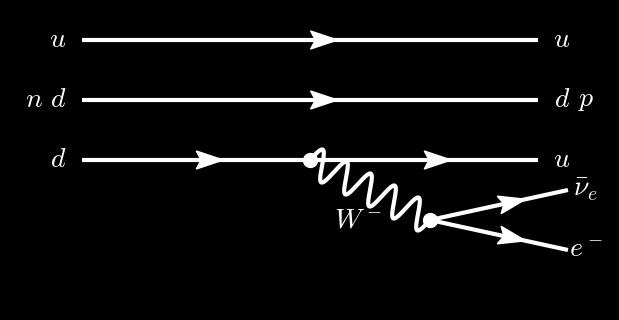

In [256]:


#Theme.set("light")
Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}

fig = plt.figure(figsize=(10*0.6,5*0.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)

dX = 0
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 0.5)

# Создаём диаграмму
diagram = Diagram(ax)

image_h = 0.5
# Вершины
in1 = diagram.vertex(xy=(dX+0.12, image_h-0.05), marker='', **style_params)  # u-кварк нейтрона
in2 = diagram.vertex(xy=(dX+0.12, image_h-0.15), marker='', **style_params)  # d-кварк нейтрона
in3 = diagram.vertex(xy=(dX+0.12, image_h-0.25), marker='', **style_params)  # d-кварк нейтрона

out1 = diagram.vertex(xy=(dX+0.88, image_h-0.05), marker='', **style_params)  # u-кварк протона
out2 = diagram.vertex(xy=(dX+0.88, image_h-0.15), marker='', **style_params)  # d-кварк протона
out3 = diagram.vertex(xy=(dX+0.88, image_h-0.25), marker='', **style_params)  # u-кварк протона

v1 = diagram.vertex(xy=(dX+0.5, image_h-0.25), **style_params)  # W
v2 = diagram.vertex(xy=(dX+0.7, image_h-0.35), **style_params)  # W

out_e = diagram.vertex(xy=(dX+0.93, image_h-0.4), marker='', **style_params)   # электрон
out_nu = diagram.vertex(xy=(dX+0.93, image_h-0.3), marker='', **style_params)  # антинейтрино

# Линии кварков
u_line = diagram.line(in1, out1, **style_params, arrow_param=style_params)
d_line1 = diagram.line(in2, out2, **style_params, arrow_param=style_params)
d_line2 = diagram.line(in3, v1, **style_params, arrow_param=style_params)
u_out = diagram.line(v1, out3, **style_params, arrow_param=style_params)

# W-бозон
w_line = diagram.line(v1, v2, style='wiggly', **style_params)
nu_line = diagram.line(v2, out_nu, arrow=True, **style_params, arrow_param=style_params)
vd_line = diagram.line(v2, out_e, **style_params, arrow_param=style_params)

# Текст
diagram.text(dX+0.08, image_h-0.05, r"$u$", fontsize=20)
diagram.text(dX+0.08, image_h-0.15, r"$d$", fontsize=20)
diagram.text(dX+0.08, image_h-0.25, r"$d$", fontsize=20)

diagram.text(dX+0.92, image_h-0.05, r"$u$", fontsize=20)
diagram.text(dX+0.92, image_h-0.15, r"$d$", fontsize=20)
diagram.text(dX+0.92, image_h-0.25, r"$u$", fontsize=20)


diagram.text(v1.xy[0]+0.08, v2.xy[1], r"$W^-$", fontsize=20)
diagram.text(out_e.xy[0]+0.03, out_e.xy[1], r"$e^-$", fontsize=20)
diagram.text(out_nu.xy[0]+0.03, out_nu.xy[1], r"$\bar{\nu}_e$", fontsize=20)
diagram.text(dX+0.96, image_h-0.15, r"$p$", fontsize=20)
diagram.text(dX+0.04, image_h-0.15, r"$n$", fontsize=20)
# Отображаем диаграмму
diagram.plot()
fig.savefig(f'../docs/KaonDecay/CKM/images/n-decay-{Theme.suff()}.svg',transparent=True)

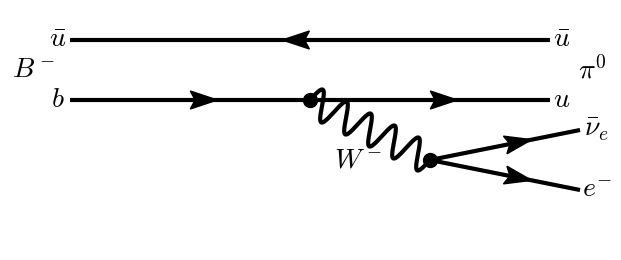

In [250]:

Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}

fig = plt.figure(figsize=(10*0.6,4*0.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)

dX = 0.0
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 0.4)

# Создаём диаграмму
diagram = Diagram(ax)

image_h = 0.4
# Вершины
in1 = diagram.vertex(xy=(dX+0.1, image_h-0.05), marker='', **style_params)  # u-кварк нейтрона
in2 = diagram.vertex(xy=(dX+0.1, image_h-0.15), marker='', **style_params)  # d-кварк нейтрона=

out1 = diagram.vertex(xy=(dX+0.9, image_h-0.05), marker='', **style_params)  # u-кварк протона
out2 = diagram.vertex(xy=(dX+0.9, image_h-0.15), marker='', **style_params)  # d-кварк протона=

v1 = diagram.vertex(xy=(dX+0.5, image_h-0.15), **style_params)  # W
v2 = diagram.vertex(xy=(dX+0.7, image_h-0.25), **style_params)  # W

out_e = diagram.vertex(xy=(dX+0.95, image_h-0.3), marker='', **style_params)   # электрон
out_nu = diagram.vertex(xy=(dX+0.95, image_h-0.2), marker='', **style_params)  # антинейтрино

# Линии кварков
u_line = diagram.line(out1, in1, **style_params, arrow_param=style_params)
d_line2 = diagram.line(in2, v1, **style_params, arrow_param=style_params)
u_out = diagram.line(v1, out2, **style_params, arrow_param=style_params)

# W-бозон
w_line = diagram.line(v1, v2, style='wiggly', **style_params)
nu_line = diagram.line(v2, out_nu, arrow=True, **style_params, arrow_param=style_params)
vd_line = diagram.line(v2, out_e, **style_params, arrow_param=style_params)

# Текст
diagram.text(dX+0.08, image_h-0.05, r"$\bar{u}$", fontsize=20)
diagram.text(dX+0.08, image_h-0.15, r"$b$", fontsize=20)

diagram.text(dX+0.92, image_h-0.05, r"$\bar{u}$", fontsize=20)
diagram.text(dX+0.92, image_h-0.15, r"$u$", fontsize=20)


diagram.text(v1.xy[0]+0.08, v2.xy[1], r"$W^-$", fontsize=20)
diagram.text(out_e.xy[0]+0.028, out_e.xy[1], r"$e^{-}$", fontsize=20)
diagram.text(out_nu.xy[0]+0.028, out_nu.xy[1], r"$\bar{\nu}_e$", fontsize=20)
diagram.text(dX+0.97, image_h-0.1, r"$\pi^0$", fontsize=20)
diagram.text(dX+0.04, image_h-0.1, r"$B^-$", fontsize=20)
# Отображаем диаграмму
diagram.plot()
fig.savefig(f'../docs/KaonDecay/CKM/images/B-decay-{Theme.suff()}.svg',transparent=True)

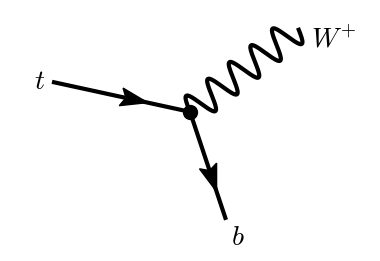

In [ ]:
Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}

fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)

dX = 0.25
ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

# Создаём диаграмму
diagram = Diagram(ax)

image_h = 0.4
cw= 0.3
# Вершины
in1 = diagram.vertex(xy=(cw-0.23, 0.28), marker='', **style_params) 
cener = diagram.vertex(xy=(cw, 0.23), **style_params) 
outW = diagram.vertex(xy=(cw+0.18, 0.37), marker='', **style_params)  
outq = diagram.vertex(xy=(cw+0.06, 0.05), marker='', **style_params)  


tin_line = diagram.line(in1, cener, **style_params, arrow_param=style_params)
qout_line = diagram.line(cener, outq, **style_params, arrow_param=style_params)
w_line = diagram.line(cener, outW, style='wiggly', **style_params)

diagram.text(in1.xy[0]-0.02, in1.xy[1], r"$t$", fontsize=20)
diagram.text(outq.xy[0]+0.02, outq.xy[1]-0.03, r"$b$", fontsize=20)
diagram.text(outW.xy[0]+0.06, outW.xy[1]-0.02, r"$W^{+}$", fontsize=20)
# Отображаем диаграмму
diagram.plot()
fig.savefig(f'../docs/KaonDecay/CKM/images/tq-decay-{Theme.suff()}.svg',transparent=True)

## Phi 4

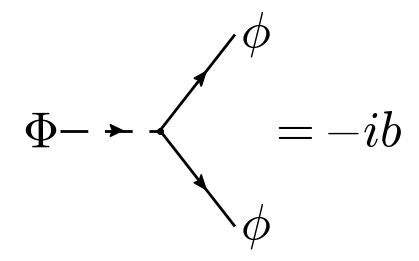

In [317]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.2), marker='', **style_params) 
center = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.45, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.45, H-0.04), marker='', **style_params)

diagram.line(in1, center, **style_params,style='dashed',linewidth=2,arrow_param=arrow_params)
diagram.line(center, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center, out2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text(in1.xy[0]-0.04, in1.xy[1]-0.005, r"$\Phi$", fontsize=36)
diagram.text(out1.xy[0]+0.04, out1.xy[1], r"$\phi$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1], r"$\phi$", fontsize=36)

diagram.text(out2.xy[0]+0.2, center.xy[1]-0.005, r"$=-ib$", fontsize=36)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/Phi-2phi-{Theme.suff()}.svg',transparent=True)

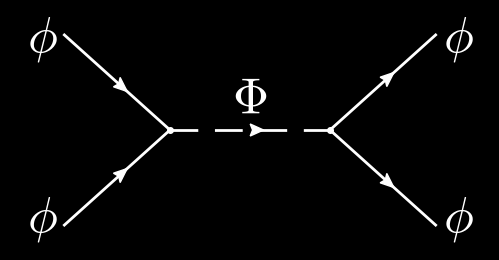

In [341]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center1 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.6, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.8, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, H-0.04), marker='', **style_params)

diagram.line(in1,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, center2, **style_params,style='dashed',linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.05, r"$\Phi$", fontsize=36)
diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/phi4-{Theme.suff()}.svg',transparent=True)

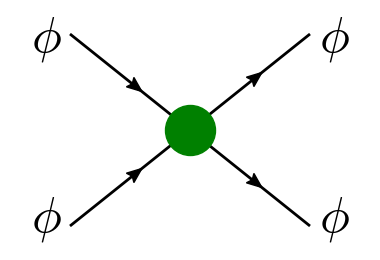

In [361]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center2 = diagram.vertex(xy=(0.3, 0.2), color="green",markersize=36)
out1 = diagram.vertex(xy=(0.5, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.5, H-0.04), marker='', **style_params)

diagram.line(in1,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/phi4_Full-{Theme.suff()}.svg',transparent=True)

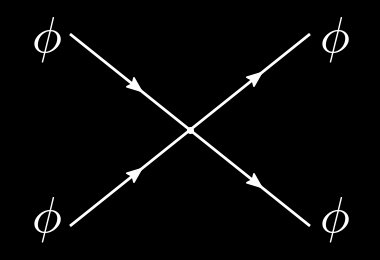

In [363]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center2 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.5, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.5, H-0.04), marker='', **style_params)

diagram.line(in1,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/phi4_EFT-{Theme.suff()}.svg',transparent=True)

In [371]:
2.4*1/0.4

5.999999999999999

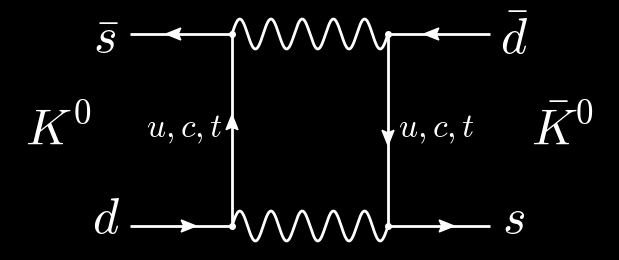

In [393]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 1)
ax.set_ylim(0, 0.4)

H = 0.4
in1_y = 0.04
in2_y = H-0.04

in1 = diagram.vertex(xy=(0.2, in1_y), marker='', **style_params)
in2 = diagram.vertex(xy=(0.2, in2_y), marker='', **style_params)

center1_u = diagram.vertex(xy=(0.37, in1_y), **style_params,markersize=4)
center1_d = diagram.vertex(xy=(0.37, in2_y), **style_params,markersize=4)

center2_u = diagram.vertex(xy=(0.63, in1_y), **style_params,markersize=4)
center2_d = diagram.vertex(xy=(0.63, in2_y), **style_params,markersize=4)

out1 = diagram.vertex(xy=(0.8, in1_y), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, in2_y), marker='', **style_params)

diagram.line(in1,center1_u, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1_d,in2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u, center2_u, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(center1_d, center2_d, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u,center1_d, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2_d,center2_u, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center2_u, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(out2,center2_d,  **style_params,linewidth=2,arrow_param=arrow_params)



diagram.text(in1.xy[0]-0.12, H/2, r"$K^{0}$", fontsize=36)
diagram.text(out1.xy[0]+0.12,H/2, r"$\bar{K}^0$", fontsize=36)

diagram.text(center1_u.xy[0]-0.08, H/2, r"$u,c,t$", fontsize=24)
diagram.text(center2_u.xy[0]+0.08, H/2, r"$u,c,t$", fontsize=24)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$s$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\bar{d}$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$d$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\bar{s}$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/Kosc-{Theme.suff()}.svg',transparent=True)

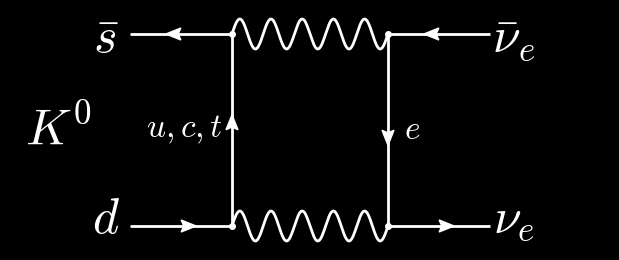

In [404]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 1)
ax.set_ylim(0, 0.4)

H = 0.4
in1_y = 0.04
in2_y = H-0.04

in1 = diagram.vertex(xy=(0.2, in1_y), marker='', **style_params)
in2 = diagram.vertex(xy=(0.2, in2_y), marker='', **style_params)

center1_u = diagram.vertex(xy=(0.37, in1_y), **style_params,markersize=4)
center1_d = diagram.vertex(xy=(0.37, in2_y), **style_params,markersize=4)

center2_u = diagram.vertex(xy=(0.63, in1_y), **style_params,markersize=4)
center2_d = diagram.vertex(xy=(0.63, in2_y), **style_params,markersize=4)

out1 = diagram.vertex(xy=(0.8, in1_y), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, in2_y), marker='', **style_params)

diagram.line(in1,center1_u, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1_d,in2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u, center2_u, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(center1_d, center2_d, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u,center1_d, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2_d,center2_u, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center2_u, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( out2,center2_d, **style_params,linewidth=2,arrow_param=arrow_params)



diagram.text(in1.xy[0]-0.12, H/2, r"$K^{0}$", fontsize=36)

diagram.text(center1_u.xy[0]-0.08, H/2, r"$u,c,t$", fontsize=24)
diagram.text(center2_u.xy[0]+0.04, H/2, r"$e$", fontsize=24)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\nu_e$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\bar{\nu}_e$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$d$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\bar{s}$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/KLDecay-{Theme.suff()}.svg',transparent=True)

## Decay $ b \to s + \gamma $

In [ ]:
from feynman import Line

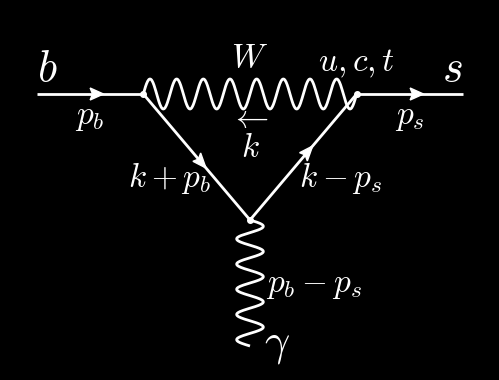

In [473]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,3.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.6)

H = 0.6

Up = H-0.14
Down = 0.04

in1 = diagram.vertex(xy=(0.05, Up), marker='', **style_params)

center1 = diagram.vertex(xy=(0.25, Up), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.65, Up), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.85, Up), marker='', **style_params)

#Line()
diagram.line(in1,center1, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1, center2, **style_params,style='wiggly',nwiggles=8,linewidth=2,arrow_param=arrow_params)
diagram.line(center2,out1, **style_params,linewidth=2,arrow_param=arrow_params)

centerL =  diagram.vertex(xy=((in1.xy[0]+out1.xy[0])/2, H/2-0.05), **style_params,markersize=4)

outG =  diagram.vertex(xy=((in1.xy[0]+out1.xy[0])/2, 0.04),marker='', **style_params,markersize=4)

diagram.line(center1, centerL, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(centerL, center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(centerL, outG, **style_params,linewidth=2,style='wiggly',arrow_param=arrow_params)

diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.06, r"$W$", fontsize=24)
diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]-0.04, r"$\leftarrow$", fontsize=24)
diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]-0.09, r"$k$", fontsize=24)
diagram.text(center2.xy[0], center2.xy[1]+0.05, r"$u,c,t$", fontsize=24)

diagram.text(out1.xy[0]-0.02, out1.xy[1]+0.04, r"$s$", fontsize=32)
diagram.text(in1.xy[0]+0.02, out1.xy[1]+0.04, r"$b$", fontsize=32)

diagram.text(center1.xy[0]+0.05, H/2+0.02, r"$k + p_b$", fontsize=24)
diagram.text(center2.xy[0]-0.03, H/2+0.02, r"$k - p_s$", fontsize=24)

diagram.text(out1.xy[0]-0.1, out1.xy[1]-0.04, r"$p_s$", fontsize=24)
diagram.text(in1.xy[0]+0.1, out1.xy[1]-0.04, r"$p_b$", fontsize=24)

diagram.text(outG.xy[0]+0.12, outG.xy[1]+0.1, r"$p_b-p_s$", fontsize=24)
diagram.text(outG.xy[0]+0.05, outG.xy[1], r"$\gamma$", fontsize=32)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/BSGamma_1-{Theme.suff()}.svg',transparent=True)

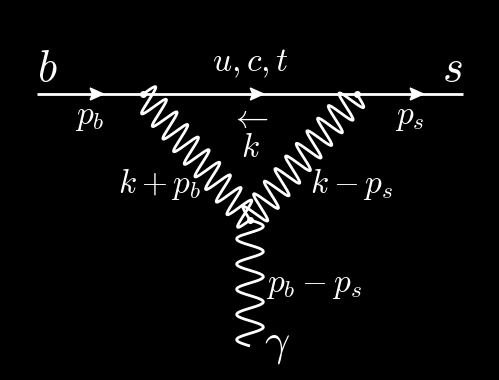

In [486]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,3.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.6)

H = 0.6

Up = H-0.14
Down = 0.04

in1 = diagram.vertex(xy=(0.05, Up), marker='', **style_params)

center1 = diagram.vertex(xy=(0.25, Up), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.65, Up), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.85, Up), marker='', **style_params)

#Line()
diagram.line(in1,center1, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1, center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2,out1, **style_params,linewidth=2,arrow_param=arrow_params)

centerL =  diagram.vertex(xy=((in1.xy[0]+out1.xy[0])/2, H/2-0.05), **style_params,markersize=4)

outG =  diagram.vertex(xy=((in1.xy[0]+out1.xy[0])/2, 0.04),marker='', **style_params,markersize=4)

diagram.line(center1, centerL, **style_params,linewidth=2,style='wiggly',nwiggles=10,arrow_param=arrow_params)
diagram.line(centerL, center2, **style_params,linewidth=2,style='wiggly',nwiggles=10,arrow_param=arrow_params)

diagram.line(centerL, outG, **style_params,linewidth=2,style='wiggly',arrow_param=arrow_params)

diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.05, r"$u,c,t$", fontsize=24)
diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]-0.04, r"$\leftarrow$", fontsize=24)
diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]-0.09, r"$k$", fontsize=24)
diagram.text(out1.xy[0]-0.02, out1.xy[1]+0.04, r"$s$", fontsize=32)
diagram.text(in1.xy[0]+0.02, out1.xy[1]+0.04, r"$b$", fontsize=32)

diagram.text(center1.xy[0]+0.03, H/2+0.01, r"$k + p_b$", fontsize=24)
diagram.text(center2.xy[0]-0.01, H/2+0.01, r"$k - p_s$", fontsize=24)

diagram.text(out1.xy[0]-0.1, out1.xy[1]-0.04, r"$p_s$", fontsize=24)
diagram.text(in1.xy[0]+0.1, out1.xy[1]-0.04, r"$p_b$", fontsize=24)

diagram.text(outG.xy[0]+0.12, outG.xy[1]+0.1, r"$p_b-p_s$", fontsize=24)
diagram.text(outG.xy[0]+0.05, outG.xy[1], r"$\gamma$", fontsize=32)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/BSGamma_2-{Theme.suff()}.svg',transparent=True)

## Oprator renormalization in QFT

### Example with QED

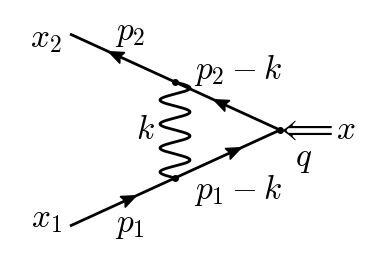

In [60]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center = diagram.vertex(xy=(0.45, 0.2), **style_params,markersize=4)

a_c = 0.5
b_c = 1-a_c
center1 = diagram.vertex(xy=a_c*in1.xy+b_c*center.xy, **style_params,markersize=4)
center2 = diagram.vertex(xy=a_c*in2.xy+b_c*center.xy, **style_params,markersize=4)

diagram.line(in1,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2,in2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1,center, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center,center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1,center2, **style_params,style='wiggly',linewidth=2, nwiggles=4,arrow_param=arrow_params)

diagram.text(in1.xy[0]-0.04, in1.xy[1]+0.01, r"$x_1$", fontsize=24)
diagram.text(in2.xy[0]-0.04, in2.xy[1]-0.01, r"$x_2$", fontsize=24)

diagram.text(center.xy[0]+0.11, center.xy[1], r"$x$", fontsize=24)

diagram.text(center.xy[0]+0.04, center.xy[1], r"$\Longleftarrow$", fontsize=24)
diagram.text(center.xy[0]+0.04, center.xy[1]-0.05, r"$q$", fontsize=24)

diagram.text( 0.2,0.04,r'$p_1$', fontsize=24)
diagram.text( 0.2,H-0.04,r'$p_2$', fontsize=24)
diagram.text(center1.xy[0]-0.05,center.xy[1],r'$k$', fontsize=24)
diagram.text(0.38,0.1,r'$p_1 - k$', fontsize=24)
diagram.text(0.38,H-0.1,r'$p_2 - k$', fontsize=24)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/RenormJ-1-{Theme.suff()}.svg',transparent=True)

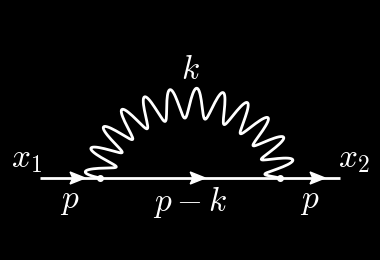

In [94]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.05, 0.12), marker='', **style_params)
out1 = diagram.vertex(xy=(0.55, 0.12), marker='', **style_params)

a_c = 0.8
b_c = 1-a_c
#Line()

center1 = diagram.vertex(xy=a_c*in1.xy+b_c*out1.xy, **style_params,markersize=4)
center2 = diagram.vertex(xy=a_c*out1.xy+b_c*in1.xy, **style_params,markersize=4)

diagram.line(in1,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2,out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1,center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1,center2, **style_params,style='wiggly',shape="elliptic",circle_angle =2, linewidth=2, nwiggles=12,arrow_param=arrow_params)

diagram.text(in1.xy[0]-0.023, in1.xy[1]+0.03, r"$x_1$", fontsize=24)
diagram.text(out1.xy[0]+0.023, out1.xy[1]+0.03, r"$x_2$", fontsize=24)

diagram.text( in1.xy[0]+0.05,in1.xy[1]-0.04,r'$p$', fontsize=24)
diagram.text( out1.xy[0]-0.05,out1.xy[1]-0.04,r'$p$', fontsize=24)
diagram.text(0.3,0.3,r'$k$', fontsize=24)
diagram.text(0.3,out1.xy[1]-0.04,r'$p - k$', fontsize=24)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/RenormJ-2-{Theme.suff()}.svg',transparent=True)

## Effective operators Weak

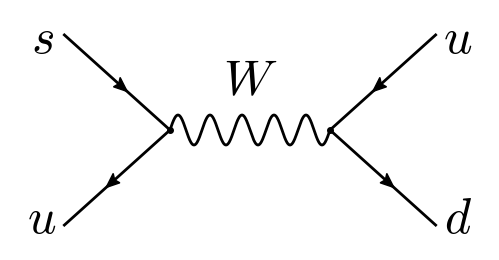

In [115]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center1 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.6, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.8, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, H-0.04), marker='', **style_params)

diagram.line(center1,in1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, center2, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( out2,center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.08, r"$W$", fontsize=36)
diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$d$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$u$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$u$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$s$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/Wsuud-{Theme.suff()}.svg',transparent=True)

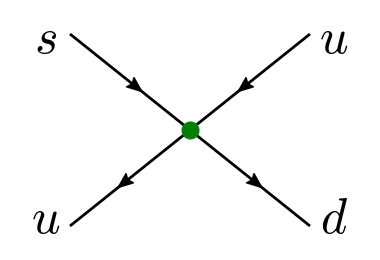

In [117]:
Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center2 = diagram.vertex(xy=(0.3, 0.2), color="green",markersize=12)
out1 = diagram.vertex(xy=(0.5, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.5, H-0.04), marker='', **style_params)

diagram.line(center2,in1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( out2,center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$d$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$u$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$u$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$s$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/suudEff1-{Theme.suff()}.svg',transparent=True)

## L4 renorm

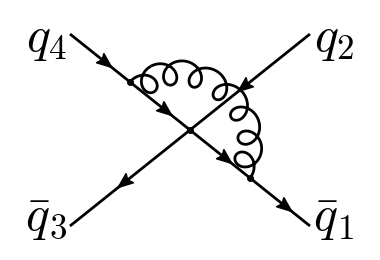

In [184]:
Theme.set("light")
#Theme.set("dark")

gluon_in = 2
gluon_out = 1

main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}

fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4


in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)

center2 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.5, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.5, H-0.04), marker='', **style_params)


if(gluon_in == 1):
    p_gluon_in = diagram.vertex(xy=(in1.xy+center2.xy)/2, **style_params,markersize=4)
else:
    p_gluon_in = diagram.vertex(xy=(in2.xy+center2.xy)/2, **style_params,markersize=4)

if(gluon_out == 1):
    p_gluon_out = diagram.vertex(xy=(out1.xy+center2.xy)/2, **style_params,markersize=4)
else:
    p_gluon_out = diagram.vertex(xy=(out2.xy+center2.xy)/2, **style_params,markersize=4)

if(gluon_in == 1):
    diagram.line(p_gluon_in,in1, **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(center2,p_gluon_in, **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(in2,center2, **style_params,linewidth=2,arrow_param=arrow_params)
else:
    diagram.line(in2,p_gluon_in ,**style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(p_gluon_in,center2, **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(center2,in1, **style_params,linewidth=2,arrow_param=arrow_params)

if(gluon_out == 1):
    diagram.line(center2,p_gluon_out, **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(p_gluon_out,out1, **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line( out2,center2, **style_params,linewidth=2,arrow_param=arrow_params)
else:
    diagram.line(p_gluon_out,center2, **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(out2,p_gluon_out, **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line( center2,out1, **style_params,linewidth=2,arrow_param=arrow_params)

if(gluon_in == gluon_out):
    Gluon = Line(
        p_gluon_in, p_gluon_out, **style_params,
        style='loopy', linewidth=2, nloops=5,
        phase=0.,xamp=0.02,yamp=(gluon_in-1.5)*2*0.02,
        arrow_param=arrow_params)
    diagram.add_line(Gluon)
else:
    Gluon = Line(
        p_gluon_in, p_gluon_out, **style_params,
        style='loopy', linewidth=2, nloops=7,shape="elliptic",
        phase=0.,xamp=0.02,yamp=-0.02,
        arrow_param=arrow_params)
    diagram.add_line(Gluon)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\bar{q}_1$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$q_2$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$\bar{q}_3$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$q_4$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/L4suud-{gluon_in}{gluon_out}-{Theme.suff()}.svg',transparent=True)

In [136]:
Line

Object `Line.__init__` not found.


## SU(3) Diagramm

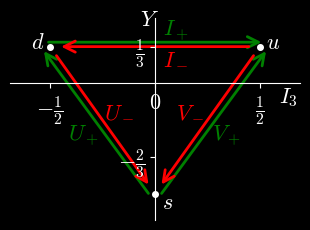

In [60]:
#Theme.set("light")
Theme.set("dark")

main_color = Theme.color()

from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(3.2, 2.4),frameon=True)

quarks = {
    's': (0, -1),
    'u': (0.5, 1/3),
    'd': (-0.5, 1/3),
}

dh1 = 0.08
dh2 = 0.04
quark_offsets= {
    's': (0.06, -dh1),
    'u': ((dh2+dh1)/2, dh2),
    'd': (-(dh2+dh1)/2, dh2),
}

arrow_offsets = {
    's': (0, -dh1),
    'u': ((dh2+dh1)/2, dh2),
    'd': (-(dh2+dh1)/2, dh2),
}


operators = {
    'I_+': {'start': 'd', 'end': 'u', 'offset': (0.1, 0.1), 'color': 'green'},
    'I_-': {'start': 'u', 'end': 'd', 'offset': (0.1, -0.1), 'color': 'red'},
    'U_+': {'start': 's', 'end': 'd', 'offset': (-0.06, -0.12), 'color': 'green'},
    'U_-': {'start': 'd', 'end': 's', 'offset': (0.08, +0.08), 'color': 'red'},
    'V_+': {'start': 's', 'end': 'u', 'offset': (0.06, -0.12), 'color': 'green'},
    'V_-': {'start': 'u', 'end': 's', 'offset': (-0.08, 0.08), 'color': 'red'},
}

# Рисуем кварки
for quark, (x, y) in quarks.items():
    ax.plot(x, y, 'o', markersize=4, color=main_color, linewidth=2)
    (dx,dy) = quark_offsets[quark]
    ax.text(x+dx, y+dy, f'${quark}$', fontsize=16, ha='center', va='center', fontweight='bold')


# Рисуем стрелки операторов
for op_name, op_info in operators.items():

    start_x, start_y = quarks[op_info['start']]
    end_x, end_y = quarks[op_info['end']]
    
    # Сдвигаем начало и конец для избежания наложения

    
    if(op_name.endswith('_-')):
        dx_start = 0
        dy_start = 0
        dx_end = 0
        dy_end = 0
    else:
        (dx_start, dy_start) = arrow_offsets[op_info['start']]
        (dx_end, dy_end) = arrow_offsets[op_info['end']]
    
    start_y = start_y + dy_start
    start_x = start_x + dx_start
    end_y = end_y + dy_end
    end_x = end_x + dx_end
    
    # Рисуем стрелку
    arrow = FancyArrowPatch(posA=(start_x, start_y), 
                        posB=(end_x, end_y),
                        arrowstyle='->', 
                        mutation_scale=20,
                        color=op_info['color'],
                        linewidth=2,
                        shrinkA=8,
                        shrinkB=8,
                        zorder=1)  # Низкий zorder для стрелок

    ax.add_patch(arrow)
    
    # Подписываем оператор (сдвигаем подпись наружу/внутрь)
    
    (tx_tmp, ty_tmp) = op_info['offset']
    text_x = (start_x + end_x) / 2 + tx_tmp 
    text_y = (start_y + end_y) / 2 + ty_tmp

    ax.text(text_x, text_y, f'${op_name}$', fontsize=16, 
            color=op_info['color'], fontweight='bold',
            ha='center', va='center')
    

# подаиси x оси (-$\frac{1}{2}$ 0 1/2)
#сделать через ax.set_xticks и ax.set_xticklabels
ax.set_axisbelow(False)
ax.set_xticks([-0.5, 0, 0.5])
ax.set_xticklabels([r'$-\frac{1}{2}$', r'$0$', r'$\frac{1}{2}$'])
# подписи y оси (-2/3 1/3)
ax.set_yticks([-2/3, 1/3])
ax.set_yticklabels([r'$-\frac{2}{3}$', r'$\frac{1}{3}$'])
ax.tick_params(axis='both', labelsize=16)

# ensure ticks and labels are drawn above other artists

for t in ax.xaxis.get_ticklines() + ax.yaxis.get_ticklines():
    t.set_zorder(10)
for lbl in ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels():
    lbl.set_zorder(10)
# хочу подписи на краях осей
# place axes at center, add arrowheads and labels
x_label = r'$I_3$'
y_label = r'$Y$'

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
padx = 0.08 * (xmax - xmin)
pady = 0.08 * (ymax - ymin)
ax.set_xlim(xmin - padx, xmax + padx)
ax.set_ylim(ymin - pady, ymax + pady)

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(main_color)
ax.spines['bottom'].set_color(main_color)



# labels near the arrow tips
ax.text(ax.get_xlim()[1] - 0.01*(xmax-xmin), -0.01*(ymax-ymin), x_label,
        fontsize=16, ha='right', va='top')
ax.text(-0.06*(xmax-xmin), ax.get_ylim()[1] + 0.05*(ymax-ymin), y_label,
        fontsize=16, ha='left', va='top')



plt.tight_layout()
plt.show()
fig.savefig(f'../docs/KaonDecay/FCNC/images/YI3-{Theme.suff()}.svg',transparent=True)

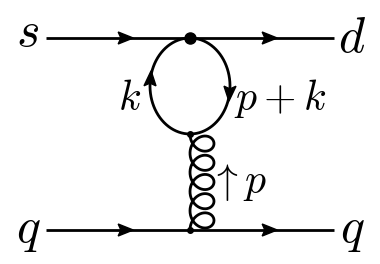

In [138]:
Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4

in1 = diagram.vertex(xy=(0.06, H-0.04), marker='', **style_params)
out1 = diagram.vertex(xy=(0.54, H-0.04), marker='', **style_params)

in2 = diagram.vertex(xy=(0.06, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.54, 0.04), marker='', **style_params)

center12 = diagram.vertex(xy=(0.3, H-0.04),markersize=8, **style_params)

centerU = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
centerD = diagram.vertex(xy=(0.3, 0.04), **style_params,markersize=4)

diagram.line(center12,centerU, **style_params,linewidth=2,shape="elliptic",arrow_param=arrow_params)
diagram.line(centerU,center12, **style_params,linewidth=2,shape="elliptic",arrow_param=arrow_params)

diagram.line(in1,center12, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,centerD, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center12, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( centerD,centerU, **style_params,linewidth=2,style='loopy',phase=0.0,xamp=0.02,yamp=-0.02,nloops=5.0,arrow_param=arrow_params)

diagram.line( centerD,out2, **style_params,linewidth=2,arrow_param=arrow_params)


diagram.text(centerU.xy[0]-0.1, centerU.xy[1]+0.06, r"$k$", fontsize=30)
diagram.text(centerU.xy[0]+0.15, centerU.xy[1]+0.06, r"$p+k$", fontsize=30)

diagram.text(centerU.xy[0]+0.08, centerU.xy[1]-0.08, r"$\uparrow p$", fontsize=30)

diagram.text(out1.xy[0]+0.03, out1.xy[1]+0.0, r"$d$", fontsize=36)
diagram.text(out2.xy[0]+0.03, out2.xy[1]-0.00, r"$q$", fontsize=36)
diagram.text(in1.xy[0]-0.03, out1.xy[1]+0.01, r"$s$", fontsize=36)
diagram.text(in2.xy[0]-0.03, out2.xy[1]-0.00, r"$q$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/PinguinFermi-{Theme.suff()}.svg',transparent=True)

## Kaon Decay

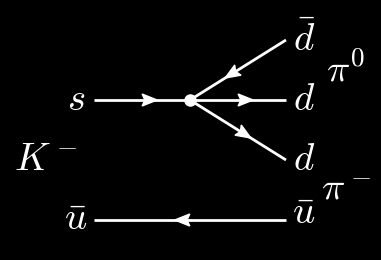

In [188]:
#Theme.set("light")
Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.14, 0.25), marker='', **style_params)
in2 = diagram.vertex(xy=(0.14, 0.05), marker='', **style_params)

center = diagram.vertex(xy=(0.3, 0.25), **style_params,markersize=8)

out1 = diagram.vertex(xy=(0.46, 0.05), marker='', **style_params)
out2 = diagram.vertex(xy=(0.46, 0.15), marker='', **style_params)
out3 = diagram.vertex(xy=(0.46, 0.25), marker='', **style_params)
out4 = diagram.vertex(xy=(0.46, 0.35), marker='', **style_params)

diagram.line(in1,center, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center,out2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center, out3, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( out4,center, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line( out1,in2, **style_params,linewidth=2,arrow_param=arrow_params)


diagram.text(out1.xy[0]+0.03, out1.xy[1]+0.01, r"$\bar{u}$", fontsize=28)


diagram.text(out2.xy[0]+0.03, out2.xy[1], r"$d$", fontsize=28)
diagram.text(out3.xy[0]+0.03, out3.xy[1], r"$d$", fontsize=28)
diagram.text(out4.xy[0]+0.03, out4.xy[1], r"$\bar{d}$", fontsize=28)

diagram.text(in1.xy[0]-0.03, in1.xy[1], r"$s$", fontsize=28)
diagram.text(in2.xy[0]-0.03, in2.xy[1], r"$\bar{u}$", fontsize=28)

diagram.text( (in1.xy[0]+in2.xy[0])/2-0.08, (in1.xy[1]+in2.xy[1])/2, r"$K^-$", fontsize=28)
diagram.text( (out1.xy[0]+out2.xy[0])/2+0.1, (out1.xy[1]+out2.xy[1])/2, r"$\pi^-$", fontsize=28)
diagram.text( (out3.xy[0]+out4.xy[0])/2+0.1, (out3.xy[1]+out4.xy[1])/2, r"$\pi^0$", fontsize=28)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/KaonDecay3-{Theme.suff()}.svg',transparent=True)

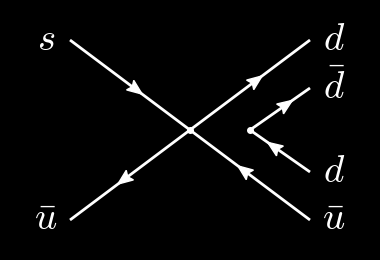

In [204]:
#Theme.set("light")
Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.05), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.05), marker='', **style_params)
center2 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.5, 0.05), marker='', **style_params)
out2 = diagram.vertex(xy=(0.5, H-0.05), marker='', **style_params)

center1 = diagram.vertex(xy=(0.4, 0.2), **style_params,markersize=4)
out3 = diagram.vertex(xy=(0.5, 0.13), marker='', **style_params)
out4 = diagram.vertex(xy=(0.5, 0.27), marker='', **style_params)

diagram.line(out3,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, out4, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center2,in1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( out1,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( center2,out2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text(out2.xy[0]+0.04, out2.xy[1], r"$d$", fontsize=28)
diagram.text(out1.xy[0]+0.04, out1.xy[1], r"$\bar{u}$", fontsize=28)
diagram.text(in1.xy[0]-0.04, out1.xy[1], r"$\bar{u}$", fontsize=28)
diagram.text(in2.xy[0]-0.04, out2.xy[1], r"$s$", fontsize=28)

diagram.text(out3.xy[0]+0.04, out3.xy[1], r"$d$", fontsize=28)
diagram.text(out4.xy[0]+0.04, out4.xy[1], r"$\bar{d}$", fontsize=28)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/KaonCancel2-{Theme.suff()}.svg',transparent=True)

## sdsdOSC

In [207]:
0.8/0.4*2.4

4.8

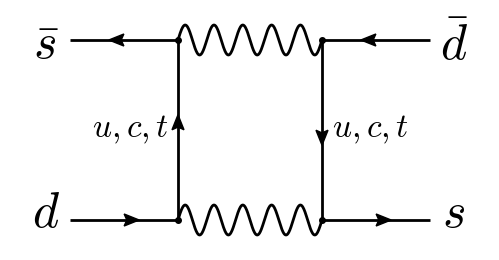

In [ ]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.4)

H = 0.4
in1_y = 0.05
in2_y = H-0.05

in1 = diagram.vertex(xy=(0.1, in1_y), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, in2_y), marker='', **style_params)

center1_u = diagram.vertex(xy=(0.28, in1_y), **style_params,markersize=4)
center1_d = diagram.vertex(xy=(0.28, in2_y), **style_params,markersize=4)

center2_u = diagram.vertex(xy=(0.52, in1_y), **style_params,markersize=4)
center2_d = diagram.vertex(xy=(0.52, in2_y), **style_params,markersize=4)

out1 = diagram.vertex(xy=(0.7, in1_y), marker='', **style_params)
out2 = diagram.vertex(xy=(0.7, in2_y), marker='', **style_params)

diagram.line(in1,center1_u, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1_d,in2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u, center2_u, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(center1_d, center2_d, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u,center1_d, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2_d,center2_u, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center2_u, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(out2,center2_d,  **style_params,linewidth=2,arrow_param=arrow_params)


diagram.text(center1_u.xy[0]-0.08, H/2, r"$u,c,t$", fontsize=24)
diagram.text(center2_u.xy[0]+0.08, H/2, r"$u,c,t$", fontsize=24)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$s$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\bar{d}$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$d$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\bar{s}$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/CP/images/KoscW-{Theme.suff()}.svg',transparent=True)

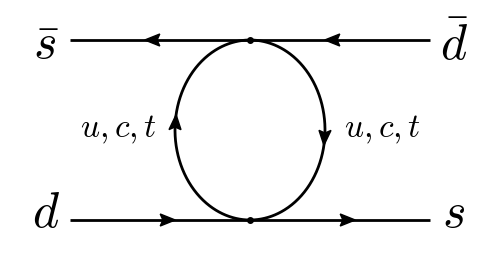

In [ ]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.4)

H = 0.4
in1_y = 0.05
in2_y = H-0.05

in1 = diagram.vertex(xy=(0.1, in1_y), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, in2_y), marker='', **style_params)

center_u = diagram.vertex(xy=(0.4, in1_y), **style_params,markersize=4)
center_d = diagram.vertex(xy=(0.4, in2_y), **style_params,markersize=4)

out1 = diagram.vertex(xy=(0.7, in1_y), marker='', **style_params)
out2 = diagram.vertex(xy=(0.7, in2_y), marker='', **style_params)

diagram.line(in1,center_u, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center_d,in2, **style_params,linewidth=2,arrow_param=arrow_params)


diagram.line(center_u,center_d, **style_params,shape='elliptic' ,linewidth=2,arrow_param=arrow_params)
diagram.line(center_d,center_u, **style_params,shape='elliptic',linewidth=2,arrow_param=arrow_params)

diagram.line(center_u, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(out2,center_d,  **style_params,linewidth=2,arrow_param=arrow_params)


diagram.text(center_u.xy[0]-0.22, H/2, r"$u,c,t$", fontsize=24)
diagram.text(center_u.xy[0]+0.22, H/2, r"$u,c,t$", fontsize=24)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$s$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\bar{d}$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$d$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\bar{s}$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/CP/images/KoscEFF-{Theme.suff()}.svg',transparent=True)

## plots for gamma

In [9]:
import numpy as np
import pandas as pd

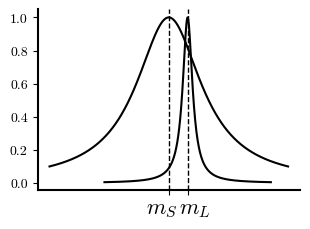

In [ ]:
Theme.set("light")
#Theme.set("dark")
key = 'K'

main_color = Theme.color()

fig, ax = plt.subplots(figsize=(3.2, 2.4),frameon=True)


Mesons = {'K':{'DeltaM':3.5,'Gamma_S':7.4,'Gamma_L':1.1,'tresh':0.005},
        'Bd':{'DeltaM':3.3,'Gamma_S':4.3,'Gamma_L':4.3,'tresh':0.005},
        'Bs':{'DeltaM':1.2,'Gamma_S':4.3e-2,'Gamma_L':4.3e-2,'tresh':0.005}  
        }

Properties = Mesons[key]

width_sigma = 3

Gs = Properties['Gamma_S']
Gl = Properties['Gamma_L']

x_s_0 = 0
x_s_1 = Gs*2*width_sigma

x_s_point = 0.5*(x_s_1+x_s_0)

x_l_point = x_s_point + Properties['DeltaM']

x_l_0 = x_l_point-Gl*width_sigma
x_l_1 = x_l_point+Gl*width_sigma

x_max = max(x_l_1,x_s_1)

x = np.linspace(x_s_0,x_max,1000)

y1 = Gs**2/((x-x_s_point)**2+Gs**2)
y2 = Gl**2/((x-x_l_point)**2+Gl**2)

df1 = pd.DataFrame({'x': x, 'y1': y1})
df2 = pd.DataFrame({'x': x, 'y2': y2})

df1 = df1[df1['y1'] > Properties['tresh']]
df2 = df2[df2['y2'] > Properties['tresh']]

x_max = max(df1['x'].max(), df2['x'].max())

# draw spectra with main_color
ax.plot(df1['x'], df1['y1'], color=main_color, lw=1.5)
ax.plot(df2['x'], df2['y2'], color=main_color, lw=1.5)

# vertical dashed lines from bottom to top
ax.axvline(x_s_point, color=main_color, linestyle='--', linewidth=1, ymin=0, ymax=1)
ax.axvline(x_l_point, color=main_color, linestyle='--', linewidth=1, ymin=0, ymax=1)

# set x-ticks at resonance positions (ticks stay at peaks)
ax.set_xticks([x_s_point, x_l_point])
# compute horizontal shift for text labels when peaks are close
dx = 0
if (x_l_point - x_s_point < x_max * 0.14):
    dx = (x_max * 0.14 - (x_l_point - x_s_point))
# label positions are shifted: left label to the left, right label to the right
label_positions = [x_s_point - dx / 2, x_l_point + dx / 2]
# remove default tick labels (we'll draw labels manually at shifted positions)
ax.set_xticklabels(['', ''])
# y position for labels: slightly below axis bottom
y_label_pos = ax.get_ylim()[0] - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0])
for xp, lbl in zip(label_positions, [r'$m_S$', r'$m_L$']):
    ax.text(xp, y_label_pos, lbl, fontsize=16, ha='center', va='top', color=main_color)

# standard axes positioning (left and bottom)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(main_color)
ax.spines['bottom'].set_color(main_color)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# color ticks to match main_color
ax.tick_params(axis='x', colors=main_color)
ax.tick_params(axis='y', colors=main_color)

plt.tight_layout()
plt.show()
fig.savefig(f'../docs/KaonDecay/CP/images/Spectra-{key}-{Theme.suff()}.svg', transparent=True)


## B decay and oscillation

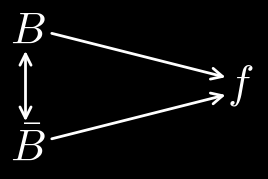

In [117]:
#Theme.set("light")
Theme.set("dark")

main_color = Theme.color()

from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(3.2, 2.0),frameon=True)

ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

#remove borders
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.5)

Р = 0.5

ax.text(0, 0.01, '$\\bar{B}$', fontsize=32)
ax.text(0, 0.39, '$B$', fontsize=32)

ax.text(0.7, 0.22, '$f$', fontsize=32)

arrow1 = FancyArrowPatch(posA=(0.1, 0.07), 
                        posB=(0.73, 0.23),
                        arrowstyle='->', 
                        mutation_scale=20,
                        linewidth=2,
                        shrinkA=8,
                        shrinkB=8)
arrow2 = FancyArrowPatch(posA=(0.1, 0.43), 
                        posB=(0.73, 0.27),
                        arrowstyle='->', 
                        mutation_scale=20,
                        linewidth=2,
                        shrinkA=8,
                        shrinkB=8)

arrow3 = FancyArrowPatch(posA=(0.05, 0.4), 
                        posB=(0.05, 0.1),
                        arrowstyle='<->', 
                        mutation_scale=20,
                        linewidth=2,
                        shrinkA=8,
                        shrinkB=8)

ax.add_patch(arrow1)
ax.add_patch(arrow2)
ax.add_patch(arrow3)

plt.show()
fig.savefig(f'../docs/KaonDecay/CP/images/BbarBf-{Theme.suff()}.svg', transparent=True)

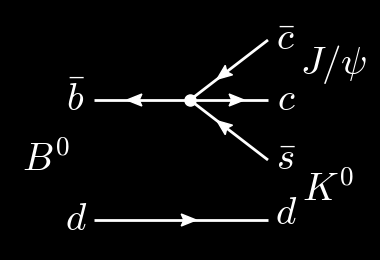

In [170]:
#Theme.set("light")
Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.14, 0.25), marker='', **style_params)
in2 = diagram.vertex(xy=(0.14, 0.05), marker='', **style_params)

center = diagram.vertex(xy=(0.3, 0.25), **style_params,markersize=8)

out1 = diagram.vertex(xy=(0.43, 0.05), marker='', **style_params)
out2 = diagram.vertex(xy=(0.43, 0.15), marker='', **style_params)
out3 = diagram.vertex(xy=(0.43, 0.25), marker='', **style_params)
out4 = diagram.vertex(xy=(0.43, 0.35), marker='', **style_params)

diagram.line(center,in1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(out2,center, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center, out3, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(  out4,center, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line( in2,out1, **style_params,linewidth=2,arrow_param=arrow_params)


diagram.text(out1.xy[0]+0.03, out1.xy[1]+0.01, r"$d$", fontsize=28)


diagram.text(out2.xy[0]+0.03, out2.xy[1], r"$\bar{s}$", fontsize=28)
diagram.text(out3.xy[0]+0.03, out3.xy[1], r"$c$", fontsize=28)
diagram.text(out4.xy[0]+0.03, out4.xy[1], r"$\bar{c}$", fontsize=28)

diagram.text(in1.xy[0]-0.03, in1.xy[1], r"$\bar{b}$", fontsize=28)
diagram.text(in2.xy[0]-0.03, in2.xy[1], r"$d$", fontsize=28)

diagram.text( (in1.xy[0]+in2.xy[0])/2-0.08, (in1.xy[1]+in2.xy[1])/2, r"$B^0$", fontsize=28)
diagram.text( (out1.xy[0]+out2.xy[0])/2+0.1, (out1.xy[1]+out2.xy[1])/2, r"$K^0$", fontsize=28)
diagram.text( (out3.xy[0]+out4.xy[0])/2+0.11, (out3.xy[1]+out4.xy[1])/2+0.01, r"$J/\psi$", fontsize=28)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/CP/images/BDecayTree-{Theme.suff()}.svg',transparent=True)

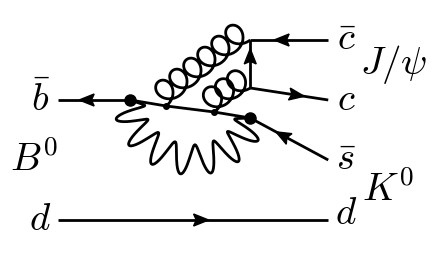

In [ ]:
Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.2,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.7)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.08, 0.25), marker='', **style_params)
in2 = diagram.vertex(xy=(0.08, 0.05), marker='', **style_params)

center1 = diagram.vertex(xy=(0.2, 0.25), **style_params,markersize=8)
center2 = diagram.vertex(xy=(0.4, 0.22), **style_params,markersize=8)

center1_1 = diagram.vertex(xy=(0.26, 0.24), **style_params,markersize=4)
center1_2 = diagram.vertex(xy=(0.34, 0.23), **style_params,markersize=4)

out1 = diagram.vertex(xy=(0.53, 0.05), marker='', **style_params)
out2 = diagram.vertex(xy=(0.53, 0.15), marker='', **style_params)
out3 = diagram.vertex(xy=(0.53, 0.25), marker='', **style_params)
out4 = diagram.vertex(xy=(0.53, 0.35), marker='', **style_params)

pre_out_1 = diagram.vertex(xy=(0.4, 0.35), marker='', **style_params)
pre_out_2 = diagram.vertex(xy=(0.4, 0.27), marker='', **style_params)


diagram.line(center1,in1, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1_1,center1, **style_params,linewidth=2,arrow=None)
diagram.line(center1_2,center1_1, **style_params,linewidth=2,arrow=None)
diagram.line(center2,center1_2, **style_params,linewidth=2,arrow=None)

diagram.line(center1_1,pre_out_1, **style_params,style='loopy',nloops=6,xamp=0.02,yamp=0.02,linewidth=2)
diagram.line(center1_2,pre_out_2, **style_params,style='loopy',nloops=3,xamp=0.02,yamp=0.02,linewidth=2)

diagram.line(center1,center2, **style_params,style='wiggly',shape='elliptic',nwiggles=7.5,ellipse_spread=-0.5, linewidth=2)
diagram.line(out2,center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(pre_out_2, out3, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( out4,pre_out_1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(pre_out_2,pre_out_1, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line( in2,out1, **style_params,linewidth=2,arrow_param=arrow_params)


diagram.text(out1.xy[0]+0.03, out1.xy[1]+0.01, r"$d$", fontsize=28)


diagram.text(out2.xy[0]+0.03, out2.xy[1], r"$\bar{s}$", fontsize=28)
diagram.text(out3.xy[0]+0.03, out3.xy[1], r"$c$", fontsize=28)
diagram.text(out4.xy[0]+0.03, out4.xy[1], r"$\bar{c}$", fontsize=28)

diagram.text(in1.xy[0]-0.03, in1.xy[1], r"$\bar{b}$", fontsize=28)
diagram.text(in2.xy[0]-0.03, in2.xy[1], r"$d$", fontsize=28)

diagram.text( (in1.xy[0]+in2.xy[0])/2-0.04, (in1.xy[1]+in2.xy[1])/2, r"$B^0$", fontsize=28)
diagram.text( (out1.xy[0]+out2.xy[0])/2+0.1, (out1.xy[1]+out2.xy[1])/2, r"$K^0$", fontsize=28)
diagram.text( (out3.xy[0]+out4.xy[0])/2+0.11, (out3.xy[1]+out4.xy[1])/2+0.01, r"$J/\psi$", fontsize=28)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/CP/images/BDecayLoop-{Theme.suff()}.svg',transparent=True)

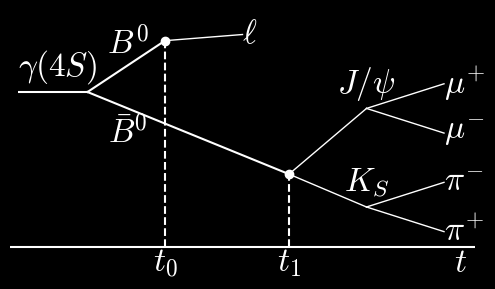

In [228]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.axis('off')

# canvas size in time/vertical units
W = 6
H = 3.2
ax.set_xlim(0, W)
ax.set_ylim(0, H)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color(main_color)
ax.spines['bottom'].set_linewidth(1)

# Use font size everywhere
fs = 24

# If coordinates are not defined earlier in the notebook, define fallbacks

gamma_start = (0.1, H * 2 / 3)
gamma_end = (1, H * 2 / 3)
B0_end = (2, H * 7 / 8)
barB0_end = (3.6, H * 1 / 3)
Jpsi_end = (4.6, H * 6 / 10)
Ks_end = (4.6, H * 2 / 10)
Pi_p_end = (5.6, H * 1 / 10)
Pi_m_end = (5.6, H * 3 / 10)
Mu_plus_end = (5.6, H * 7 / 10)
Mu_minus_end = (5.6, H * 5 / 10)
# place lepton endpoint to the right of B0 decay and above time axis
Lepton_end = (3,H*9/10)

# time axis vertical position (keep positive)
time_y = 0.12
ax.hlines(time_y, 0, W, color=main_color, linewidth=1.5)
ax.text(W - 0.1, time_y - 0.02, '$t$', ha='right', va='top', fontsize=fs, color=main_color)

# gamma(4S) production line (horizontal)
ax.hlines(gamma_start[1], gamma_start[0], gamma_end[0], color=main_color, )
ax.text(gamma_start[0], gamma_start[1] + 0.08, r'$\gamma(4S)$', fontsize=fs, va='bottom', ha='left', color=main_color)

# Branch lines to B0 (up) and barB0 (down-right)
B_pos = np.array(B0_end)
Bbar_pos = np.array(barB0_end)
ax.plot([gamma_end[0], B_pos[0]], [gamma_end[1], B_pos[1]], color=main_color, linewidth=1.5)
ax.plot([gamma_end[0], Bbar_pos[0]], [gamma_end[1], Bbar_pos[1]], color=main_color, linewidth=1.5)

# Labels at particle positions
ax.text(B_pos[0]-0.08*W, B_pos[1]-0.01*H, r'$B^{0}$', fontsize=fs, ha='center', va='center', color=main_color)
ax.text(B_pos[0]-0.08*W, gamma_end[1]-0.16*H, r'$\bar{B}^{0}$', fontsize=fs, ha='center', va='center', color=main_color)

# Decay points: use x coordinate of endpoints as decay time markers
B_decay_x = float(B0_end[0])
Bbar_decay_x = float(barB0_end[0])
B_decay = np.array([B_decay_x, B_pos[1]])
Bbar_decay = np.array([Bbar_decay_x, Bbar_pos[1]])

# B0 decay: mark point and dashed line to time axis
ax.plot([B_pos[0], B_decay[0]], [B_pos[1], B_decay[1]], color=main_color, linewidth=1)
ax.plot(B_decay[0], B_decay[1], 'o', color=main_color)
ax.vlines(B_decay[0], time_y, B_decay[1], linestyles='dashed', colors=main_color)
ax.text(B_decay[0], time_y + 0.00, r'$t_{0}$', fontsize=fs, ha='center', va='top', color=main_color)
# B0 -> lepton: draw to Lepton_end and label
ax.plot([B_decay[0], Lepton_end[0]], [B_decay[1], Lepton_end[1]], color=main_color, linewidth=1)
ax.text(Lepton_end[0], Lepton_end[1], r'$\ell$', fontsize=fs, ha='left', va='center', color=main_color)

# Bbar0 decay: mark point and dashed line to time axis
ax.plot([Bbar_pos[0], Bbar_decay[0]], [Bbar_pos[1], Bbar_decay[1]], color=main_color, linewidth=1)
ax.plot(Bbar_decay[0], Bbar_decay[1], 'o', color=main_color)
ax.vlines(Bbar_decay[0], time_y, Bbar_decay[1], linestyles='dashed', colors=main_color)
ax.text(Bbar_decay[0], time_y + 0.00, r'$t_{1}$', fontsize=fs, ha='center', va='top', color=main_color)

# From Bbar decay point, branch to J/psi (up) and K_s (down)
Jpsi_pos = np.array(Jpsi_end)
Ks_pos = np.array(Ks_end)
ax.plot([Bbar_decay[0], Jpsi_pos[0]], [Bbar_decay[1], Jpsi_pos[1]], color=main_color, linewidth=1)
ax.plot([Bbar_decay[0], Ks_pos[0]], [Bbar_decay[1], Ks_pos[1]], color=main_color, linewidth=1)
ax.text(Jpsi_pos[0], Jpsi_pos[1]+0.1*H, r'$J/\psi$', fontsize=fs, ha='center', va='center', color=main_color)
ax.text(Ks_pos[0], Ks_pos[1]+0.1*H, r'$K_{S}$', fontsize=fs, ha='center', va='center', color=main_color)

# J/psi -> mu+ mu- (use provided endpoints if available)
mu_plus = np.array(Mu_plus_end)
mu_minus = np.array(Mu_minus_end)
ax.plot([Jpsi_pos[0], mu_plus[0]], [Jpsi_pos[1], mu_plus[1]], color=main_color, linewidth=1)
ax.plot([Jpsi_pos[0], mu_minus[0]], [Jpsi_pos[1], mu_minus[1]], color=main_color, linewidth=1)
ax.text(mu_plus[0], mu_plus[1], r'$\mu^{+}$', fontsize=fs, ha='left', va='center', color=main_color)
ax.text(mu_minus[0], mu_minus[1], r'$\mu^{-}$', fontsize=fs, ha='left', va='center', color=main_color)

# K_s -> pi+ pi-
pi_plus = np.array(Pi_p_end)
pi_minus = np.array(Pi_m_end)
ax.plot([Ks_pos[0], pi_plus[0]], [Ks_pos[1], pi_plus[1]], color=main_color, linewidth=1)
ax.plot([Ks_pos[0], pi_minus[0]], [Ks_pos[1], pi_minus[1]], color=main_color, linewidth=1)
ax.text(pi_plus[0], pi_plus[1], r'$\pi^{+}$', fontsize=fs, ha='left', va='center', color=main_color)
ax.text(pi_minus[0], pi_minus[1], r'$\pi^{-}$', fontsize=fs, ha='left', va='center', color=main_color)

plt.show()
fig.savefig(f'../docs/KaonDecay/CP/images/BBDecay-{Theme.suff()}.svg',transparent=True)


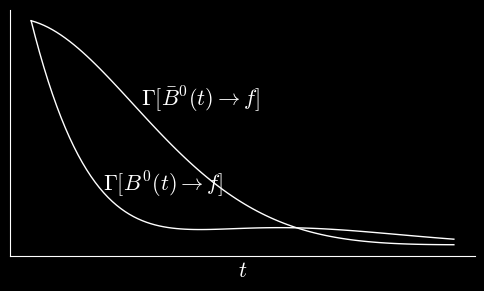

In [270]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()

fig, ax = plt.subplots(figsize=(6, 3.2))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# make axis with arrows at the end


ax.set_xticks([])
ax.set_yticks([])

t = np.linspace(0, 5, 100)

Lambda = 1
ImLambda = 0.7
Gamma_1 = np.exp(-0.8*t)*( 1+Lambda**2 + (1-Lambda**2)*np.cos(1.0*t) - 2*Lambda*ImLambda*np.sin(1.0*t) )
Gamma_2 = np.exp(-0.8*t)*( 1+Lambda**2 + (1-Lambda**2)*np.cos(1.0*t) + 2*Lambda*ImLambda*np.sin(1.0*t) )

ax.plot(t, Gamma_1, color=main_color, linewidth=1)
ax.plot(t, Gamma_2, color=main_color, linewidth=1)

ax.text(0.85, 0.55, r'$\Gamma[B^0(t)\to f]$', fontsize=16, ha='left', va='center', color=main_color)
ax.text(1.3, 1.3, r'$\Gamma[\bar{B}^0(t)\to f]$', fontsize=16, ha='left', va='center', color=main_color)

# xlabel at the end of sxis
ax.set_xlabel('$t$', fontsize=16, color=main_color)

plt.show()
fig.savefig(f'../docs/KaonDecay/CP/images/BBCPAss-{Theme.suff()}.svg',transparent=True)

## Deep Inelastic Scattering

### Muon + electron

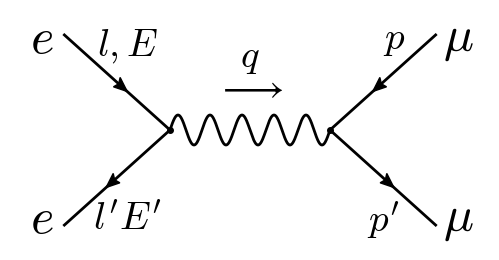

In [36]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center1 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.6, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.8, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, H-0.04), marker='', **style_params)

diagram.line(center1,in1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, center2, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( out2,center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\mu$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\mu$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$e$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$e$", fontsize=36)

diagram.text(0.45, out2.xy[1]-0.04, r"$q$", fontsize=28)
diagram.text(0.45, out2.xy[1]-0.09, r"$\longrightarrow$", fontsize=28)

diagram.text(out1.xy[0]-0.1, out1.xy[1]+0.01, r"$p'$", fontsize=28)
diagram.text(out2.xy[0]-0.08, out2.xy[1]-0.01, r"$p$", fontsize=28)

diagram.text(in1.xy[0]+0.12, out1.xy[1]+0.01, r"$l' E'$", fontsize=28)
diagram.text(in2.xy[0]+0.12, out2.xy[1]-0.02, r"$l,E$", fontsize=28)


diagram.plot()
fig.savefig(f'../docs/DeepInelastic/Partons/images/emuscat-{Theme.suff()}.svg',transparent=True)

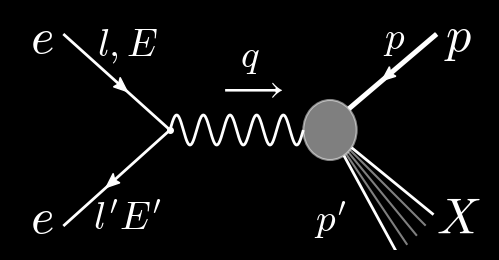

In [80]:
import numpy as np
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center1 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.55, 0.2),  marker='',**style_params)



out2 = diagram.vertex(xy=(0.8, H-0.04), marker='', **style_params)

#draw circle around center2 and fill with transparent main color 0.5 alpha, linecolor - alpha = 1

R = 0.05
C = center2.xy + (R,0)
ax.add_patch(plt.Circle(C, R, color=main_color, fill=True, alpha=0.5, linewidth=1.5))


center2_u = diagram.vertex(xy=C + (R*np.cos(np.pi/4),R*np.sin(np.pi/4)), marker='', **style_params)

angle_d = - np.pi/4*(1+0.3)
angle_u = -np.pi/4*(1-0.2)

center1_d = diagram.vertex(xy=C + (R*np.cos(angle_d),R*np.sin(angle_d)), marker='', **style_params)
center1_u = diagram.vertex(xy=C + (R*np.cos(angle_u),R*np.sin(angle_u)), marker='', **style_params)

N = 5
centres1_av = [diagram.vertex(xy=C + (R*np.cos(angle_d + i*(angle_u-angle_d)/(N-1)),R*np.sin(angle_d + i*(angle_u-angle_d)/(N-1))), marker='', **style_params) for i in range(1,N-1)]

R1 = 0.24
out1_u = diagram.vertex(xy=C + (R1*np.cos(angle_u),R1*np.sin(angle_u)), marker='', **style_params)
out1_d = diagram.vertex(xy=C + (R1*np.cos(angle_d),R1*np.sin(angle_d)), marker='', **style_params)

out1_av = [diagram.vertex(xy=C + (R1*np.cos(angle_d + i*(angle_u-angle_d)/(N-1)),R1*np.sin(angle_d + i*(angle_u-angle_d)/(N-1))), marker='', **style_params) for i in range(1,N-1)]

for (v1,v2) in zip(centres1_av, out1_av):
    diagram.line(v1,v2, **style_params,linewidth=1.5,alpha=0.5,arrow = False)

diagram.line(center1,in1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, center2, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u, out1_u, **style_params,linewidth=2,arrow = False)
diagram.line(center1_d, out1_d, **style_params,linewidth=2,arrow = False)
#Line()
diagram.line( out2,center2_u, **style_params,linewidth=2,stroke  = 'double',arrow_param=arrow_params)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$X$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$p$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$e$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$e$", fontsize=36)

diagram.text(0.45, out2.xy[1]-0.04, r"$q$", fontsize=28)
diagram.text(0.45, out2.xy[1]-0.09, r"$\longrightarrow$", fontsize=28)

diagram.text(out1.xy[0]-0.2, out1.xy[1]+0.01, r"$p'$", fontsize=28)
diagram.text(out2.xy[0]-0.08, out2.xy[1]-0.01, r"$p$", fontsize=28)

diagram.text(in1.xy[0]+0.12, out1.xy[1]+0.01, r"$l' E'$", fontsize=28)
diagram.text(in2.xy[0]+0.12, out2.xy[1]-0.02, r"$l,E$", fontsize=28)


diagram.plot()
fig.savefig(f'../docs/DeepInelastic/Partons/images/epdeep-{Theme.suff()}.svg',transparent=True)

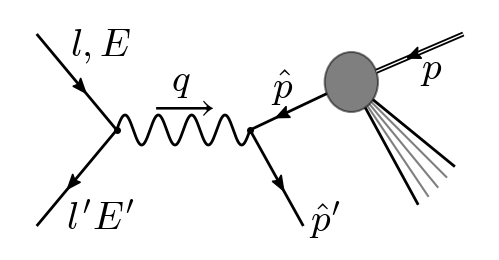

In [125]:
import numpy as np
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.05, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.05, H-0.04), marker='', **style_params)
center1 = diagram.vertex(xy=(0.2, 0.2), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.45, 0.2),**style_params,markersize=4)



out2 = diagram.vertex(xy=(0.85, H-0.04), marker='', **style_params)

out3 = diagram.vertex(xy=(0.55, 0.04), marker='', **style_params)
#draw circle around center2 and fill with transparent main color 0.5 alpha, linecolor - alpha = 1

R = 0.05
C = center2.xy*0+(0.59+R,0.28)
ax.add_patch(plt.Circle(C, R, color=main_color, fill=True, alpha=0.5, linewidth=1.5))

n3 = (center2.xy-C)/np.linalg.norm(center2.xy-C) * R
center3 = diagram.vertex(xy=C + n3,  marker='',**style_params)

n4 = (out2.xy-C)/np.linalg.norm(out2.xy-C) * R
center2_u = diagram.vertex(xy=C + n4, marker='', **style_params)

angle_d = - np.pi/4*(1+0.3)
angle_u = -np.pi/4*(1-0.2)

center1_d = diagram.vertex(xy=C + (R*np.cos(angle_d),R*np.sin(angle_d)), marker='', **style_params)
center1_u = diagram.vertex(xy=C + (R*np.cos(angle_u),R*np.sin(angle_u)), marker='', **style_params)

N = 5
centres1_av = [diagram.vertex(xy=C + (R*np.cos(angle_d + i*(angle_u-angle_d)/(N-1)),R*np.sin(angle_d + i*(angle_u-angle_d)/(N-1))), marker='', **style_params) for i in range(1,N-1)]

R1 = 0.24
out1_u = diagram.vertex(xy=C + (R1*np.cos(angle_u),R1*np.sin(angle_u)), marker='', **style_params)
out1_d = diagram.vertex(xy=C + (R1*np.cos(angle_d),R1*np.sin(angle_d)), marker='', **style_params)

out1_av = [diagram.vertex(xy=C + (R1*np.cos(angle_d + i*(angle_u-angle_d)/(N-1)),R1*np.sin(angle_d + i*(angle_u-angle_d)/(N-1))), marker='', **style_params) for i in range(1,N-1)]

for (v1,v2) in zip(centres1_av, out1_av):
    diagram.line(v1,v2, **style_params,linewidth=1.5,alpha=0.5,arrow = False)

diagram.line(center1,in1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, center2, **style_params,style='wiggly',nwiggles = 4,linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u, out1_u, **style_params,linewidth=2,arrow = False)
diagram.line(center1_d, out1_d, **style_params,linewidth=2,arrow = False)


#Line()
diagram.line( out2,center2_u, **style_params,linewidth=2,stroke  = 'double',arrow_param=arrow_params)

diagram.line(center3,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out3, **style_params,linewidth=2,arrow_param=arrow_params)    


diagram.text(0.32, out2.xy[1]-0.08, r"$q$", fontsize=28)
diagram.text(0.32, out2.xy[1]-0.12, r"$\longrightarrow$", fontsize=28)

diagram.text(out3.xy[0]+0.04, out1.xy[1]+0.01, r"$\hat{p}'$", fontsize=28)
diagram.text(out2.xy[0]-0.06, out2.xy[1]-0.06, r"$p$", fontsize=28)

diagram.text(center2.xy[0]+0.06, center2.xy[1]+0.07, r"$\hat{p}$", fontsize=28)

diagram.text(in1.xy[0]+0.12, out1.xy[1]+0.01, r"$l' E'$", fontsize=28)
diagram.text(in2.xy[0]+0.12, out2.xy[1]-0.02, r"$l,E$", fontsize=28)


diagram.plot()
fig.savefig(f'../docs/DeepInelastic/Partons/images/Parton-{Theme.suff()}.svg',transparent=True)

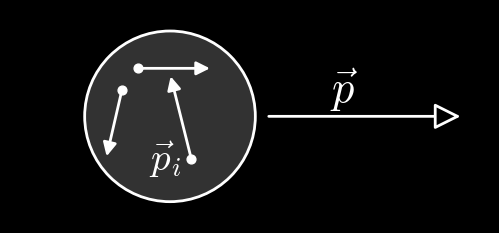

In [65]:
import numpy as np
from matplotlib.colors import to_rgba
from matplotlib.patches import FancyArrowPatch


#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()

fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)
ax.set_xticks([])
ax.set_yticks([])

fc = to_rgba(main_color, 0.2)                  # facecolor с alpha=0.2
circle = plt.Circle((0.3, 0.2), 0.16,
                    facecolor=fc,
                    edgecolor=main_color,    # контур без прозрачности
                    linewidth=2)
ax.add_patch(circle)

arrow = FancyArrowPatch((0.48, 0.2), (0.85, 0.2),
                        arrowstyle='-|>',    # треугольная голова
                        mutation_scale=40,   # размер головы
                        linewidth=2,
                        edgecolor=main_color,
                        facecolor=Theme.back())
ax.add_patch(arrow)

ax.text(0.6, 0.25, r'$\vec{p}$', fontsize=32, ha='left', va='center', color=main_color)

ax.scatter(0.34, 0.12, s=40, color=main_color)  # точка в центре круга

arrow1 = FancyArrowPatch((0.34, 0.12), (0.3, 0.28),
                        arrowstyle='-|>',    # треугольная голова
                        mutation_scale=20,   # размер головы
                        linewidth=2,
                        color=main_color)
ax.add_patch(arrow1)

ax.text(0.26, 0.12, r'$\vec{p}_i$', fontsize=28, ha='left', va='center', color=main_color)


ax.scatter(0.21, 0.25, s=40, color=main_color)  # точка в центре круга

arrow2 = FancyArrowPatch((0.21, 0.25), (0.18, 0.12),
                        arrowstyle='-|>',    # треугольная голова
                        mutation_scale=20,   # размер головы
                        linewidth=2,
                        color=main_color)
ax.add_patch(arrow2)

ax.scatter(0.24, 0.29, s=40, color=main_color)  # точка в центре круга
arrow3 = FancyArrowPatch((0.24, 0.29), (0.38, 0.29),
                        arrowstyle='-|>',    # треугольная голова
                        mutation_scale=20,   # размер головы
                        linewidth=2,
                        color=main_color)
ax.add_patch(arrow3)

ax.set_aspect('equal', adjustable='box')  # важная строка
plt.show()


fig.savefig(f'../docs/DeepInelastic/Partons/images/PartonModel-{Theme.suff()}.svg',transparent=True)

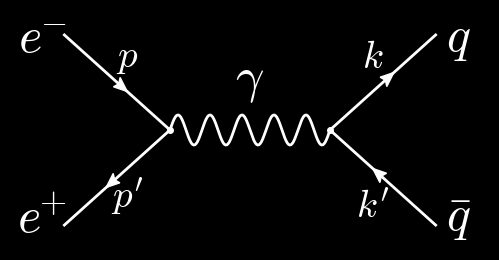

In [22]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center1 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.6, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.8, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, H-0.04), marker='', **style_params)

diagram.line(center1,in1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, center2, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(out1,center2,  **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( center2,out2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.08, r"$\gamma$", fontsize=36)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\bar{q}$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$q$", fontsize=36)


diagram.text(in2.xy[0]+0.12, out2.xy[1]-0.04, r"$p$", fontsize=28)
diagram.text(in1.xy[0]+0.12, out1.xy[1]+0.05, r"$p'$", fontsize=28)


diagram.text(out2.xy[0]-0.12, out2.xy[1]-0.04, r"$k$", fontsize=28)
diagram.text(out1.xy[0]-0.12, out1.xy[1]+0.03, r"$k'$", fontsize=28)


diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$e^{\!\!+}$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$e^{\!\!-}$", fontsize=36)


diagram.plot()

fig.savefig(f'../docs/DeepInelastic/Partons/images/EE_AA-{Theme.suff()}.svg',transparent=True)

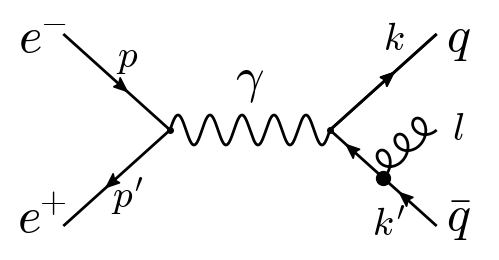

In [51]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

mode = 0

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center1 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.6, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.8, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, H-0.04), marker='', **style_params)

outg1_xy = (center2.xy + out1.xy)/2
outg2_xy = (center2.xy + out2.xy)/2

gluon_out_xy = (out1.xy + out2.xy)/2


diagram.line(center1,in1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, center2, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)

if(mode == 0): # gluon out 1
    out1g = diagram.vertex(xy=outg1_xy, **style_params)
    gluon_out = diagram.vertex(xy=gluon_out_xy, marker='', **style_params)
    diagram.line(center2,out2,  **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(out1,out1g,  **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(out1g,center2,  **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(out1g,gluon_out, **style_params,style='loopy',nloops=3,xamp=0.02,yamp=0.02,linewidth=2)
elif(mode == 1): # gluon out 2
    out2g = diagram.vertex(xy=outg2_xy, **style_params)
    diagram.line(out1,center2,  **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(out2g,out2,  **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(center2,out2g,  **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(out2g,gluon_out, **style_params,style='loopy',nloops=3,xamp=0.02,yamp=-0.02,linewidth=2)
else:
    out1g = diagram.vertex(xy=outg1_xy, **style_params)
    out2g = diagram.vertex(xy=outg2_xy, **style_params)

    diagram.line(out1,out1g,  **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(out1g,center2,  **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(out2g,out2,  **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(center2,out2g,  **style_params,linewidth=2,arrow_param=arrow_params)

    diagram.line(out1g,out2g, **style_params,style='loopy',nloops=4,xamp=0.02,yamp=-0.02,linewidth=2)

diagram.line( center2,out2, **style_params,linewidth=2,arrow_param=arrow_params)


diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.08, r"$\gamma$", fontsize=36)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\bar{q}$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$q$", fontsize=36)


diagram.text(in2.xy[0]+0.12, out2.xy[1]-0.04, r"$p$", fontsize=28)
diagram.text(in1.xy[0]+0.12, out1.xy[1]+0.05, r"$p'$", fontsize=28)

g_out_text_xy = (out1.xy + out2.xy)/2 + (0.04,0)

if(mode == 2):
    g_out_text_xy -= (0.07,0)

diagram.text(g_out_text_xy[0],g_out_text_xy[1], r"$l$", fontsize=28)

diagram.text(out2.xy[0]-0.08, out2.xy[1]-0.01, r"$k$", fontsize=28)
diagram.text(out1.xy[0]-0.09, out1.xy[1]+0.0, r"$k'$", fontsize=28)


diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$e^{\!\!+}$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$e^{\!\!-}$", fontsize=36)


diagram.plot()

fig.savefig(f'../docs/DeepInelastic/Partons/images/EE_AA-g{mode}-{Theme.suff()}.svg',transparent=True)

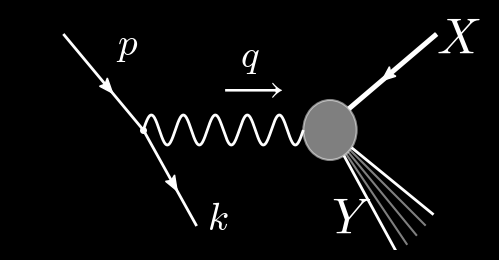

In [43]:
import numpy as np
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.35, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center1 = diagram.vertex(xy=(0.25, 0.2), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.55, 0.2),  marker='',**style_params)



out2 = diagram.vertex(xy=(0.8, H-0.04), marker='', **style_params)

#draw circle around center2 and fill with transparent main color 0.5 alpha, linecolor - alpha = 1

R = 0.05
C = center2.xy + (R,0)
ax.add_patch(plt.Circle(C, R, color=main_color, fill=True, alpha=0.5, linewidth=1.5))


center2_u = diagram.vertex(xy=C + (R*np.cos(np.pi/4),R*np.sin(np.pi/4)), marker='', **style_params)

angle_d = - np.pi/4*(1+0.3)
angle_u = -np.pi/4*(1-0.2)

center1_d = diagram.vertex(xy=C + (R*np.cos(angle_d),R*np.sin(angle_d)), marker='', **style_params)
center1_u = diagram.vertex(xy=C + (R*np.cos(angle_u),R*np.sin(angle_u)), marker='', **style_params)

N = 5
centres1_av = [diagram.vertex(xy=C + (R*np.cos(angle_d + i*(angle_u-angle_d)/(N-1)),R*np.sin(angle_d + i*(angle_u-angle_d)/(N-1))), marker='', **style_params) for i in range(1,N-1)]

R1 = 0.24
out1_u = diagram.vertex(xy=C + (R1*np.cos(angle_u),R1*np.sin(angle_u)), marker='', **style_params)
out1_d = diagram.vertex(xy=C + (R1*np.cos(angle_d),R1*np.sin(angle_d)), marker='', **style_params)

out1_av = [diagram.vertex(xy=C + (R1*np.cos(angle_d + i*(angle_u-angle_d)/(N-1)),R1*np.sin(angle_d + i*(angle_u-angle_d)/(N-1))), marker='', **style_params) for i in range(1,N-1)]

for (v1,v2) in zip(centres1_av, out1_av):
    diagram.line(v1,v2, **style_params,linewidth=1.5,alpha=0.5,arrow = False)

diagram.line(center1,in1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, center2, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u, out1_u, **style_params,linewidth=2,arrow = False)
diagram.line(center1_d, out1_d, **style_params,linewidth=2,arrow = False)
#Line()
diagram.line( out2,center2_u, **style_params,linewidth=2,stroke  = 'double',arrow_param=arrow_params)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$Y$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$X$", fontsize=36)

diagram.text(0.45, out2.xy[1]-0.04, r"$q$", fontsize=28)
diagram.text(0.45, out2.xy[1]-0.09, r"$\longrightarrow$", fontsize=28)


diagram.text(in1.xy[0]+0.04, out1.xy[1]+0.01, r"$k$", fontsize=28)
diagram.text(in2.xy[0]+0.12, out2.xy[1]-0.02, r"$p$", fontsize=28)


diagram.plot()
fig.savefig(f'../docs/DeepInelastic/Partons/images/PartonSinular1-{Theme.suff()}.svg',transparent=True)

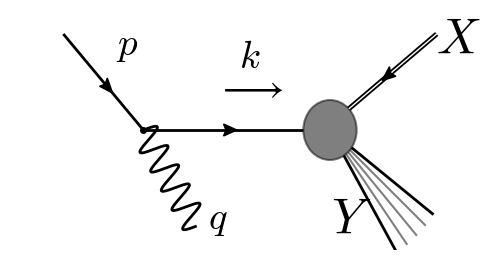

In [46]:
import numpy as np
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.35, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center1 = diagram.vertex(xy=(0.25, 0.2), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.55, 0.2),  marker='',**style_params)



out2 = diagram.vertex(xy=(0.8, H-0.04), marker='', **style_params)

#draw circle around center2 and fill with transparent main color 0.5 alpha, linecolor - alpha = 1

R = 0.05
C = center2.xy + (R,0)
ax.add_patch(plt.Circle(C, R, color=main_color, fill=True, alpha=0.5, linewidth=1.5))


center2_u = diagram.vertex(xy=C + (R*np.cos(np.pi/4),R*np.sin(np.pi/4)), marker='', **style_params)

angle_d = - np.pi/4*(1+0.3)
angle_u = -np.pi/4*(1-0.2)

center1_d = diagram.vertex(xy=C + (R*np.cos(angle_d),R*np.sin(angle_d)), marker='', **style_params)
center1_u = diagram.vertex(xy=C + (R*np.cos(angle_u),R*np.sin(angle_u)), marker='', **style_params)

N = 5
centres1_av = [diagram.vertex(xy=C + (R*np.cos(angle_d + i*(angle_u-angle_d)/(N-1)),R*np.sin(angle_d + i*(angle_u-angle_d)/(N-1))), marker='', **style_params) for i in range(1,N-1)]

R1 = 0.24
out1_u = diagram.vertex(xy=C + (R1*np.cos(angle_u),R1*np.sin(angle_u)), marker='', **style_params)
out1_d = diagram.vertex(xy=C + (R1*np.cos(angle_d),R1*np.sin(angle_d)), marker='', **style_params)

out1_av = [diagram.vertex(xy=C + (R1*np.cos(angle_d + i*(angle_u-angle_d)/(N-1)),R1*np.sin(angle_d + i*(angle_u-angle_d)/(N-1))), marker='', **style_params) for i in range(1,N-1)]

for (v1,v2) in zip(centres1_av, out1_av):
    diagram.line(v1,v2, **style_params,linewidth=1.5,alpha=0.5,arrow = False)

diagram.line(center1,in1, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)

diagram.line(in2,center1, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1, center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u, out1_u, **style_params,linewidth=2,arrow = False)
diagram.line(center1_d, out1_d, **style_params,linewidth=2,arrow = False)
#Line()
diagram.line( out2,center2_u, **style_params,linewidth=2,stroke  = 'double',arrow_param=arrow_params)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$Y$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$X$", fontsize=36)

diagram.text(0.45, out2.xy[1]-0.04, r"$k$", fontsize=28)
diagram.text(0.45, out2.xy[1]-0.09, r"$\longrightarrow$", fontsize=28)


diagram.text(in1.xy[0]+0.04, out1.xy[1]+0.01, r"$q$", fontsize=28)
diagram.text(in2.xy[0]+0.12, out2.xy[1]-0.02, r"$p$", fontsize=28)


diagram.plot()
fig.savefig(f'../docs/DeepInelastic/Partons/images/PartonSinular2-{Theme.suff()}.svg',transparent=True)

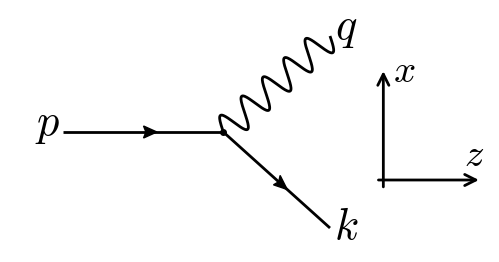

In [33]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, H/2), marker='', **style_params)

center1 = diagram.vertex(xy=(0.4, H/2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.6, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.6, H-0.04), marker='', **style_params)

diagram.line(in1,center1, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1,out2, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(center1, out1, **style_params,linewidth=2,arrow_param=arrow_params)



diagram.text(in1.xy[0]-0.03, in1.xy[1]+0.01, r"$p$", fontsize=32)
diagram.text(out1.xy[0]+0.03, out1.xy[1], r"$k$", fontsize=32)

diagram.text(out2.xy[0]+0.03, out2.xy[1]+0.01, r"$q$", fontsize=32)


from matplotlib.patches import FancyArrowPatch

Oxy_0 = (out1.xy+out2.xy)/2 + (0.1,-0.08)
arrow1 = FancyArrowPatch(posA=Oxy_0 - (0.03,0), 
                        posB=Oxy_0 + (0.2,0),
                        arrowstyle='->', 
                        mutation_scale=20,
                        linewidth=2,
                        shrinkA=8,
                        shrinkB=8)

arrow2 = FancyArrowPatch(posA=Oxy_0 - (0.0,0.03), 
                        posB=Oxy_0 + (0.0,0.2),
                        arrowstyle='->', 
                        mutation_scale=20,
                        linewidth=2,
                        shrinkA=8,
                        shrinkB=8)

ax.add_patch(arrow1)
ax.add_patch(arrow2)

diagram.text(Oxy_0[0]+0.17, Oxy_0[1]+0.04, r"$z$", fontsize=28)
diagram.text(Oxy_0[0]+0.04, Oxy_0[1]+0.18, r"$x$", fontsize=28)

diagram.plot()

fig.savefig(f'../docs/DeepInelastic/Partons/images/PartonDecoupling-{Theme.suff()}.svg',transparent=True)

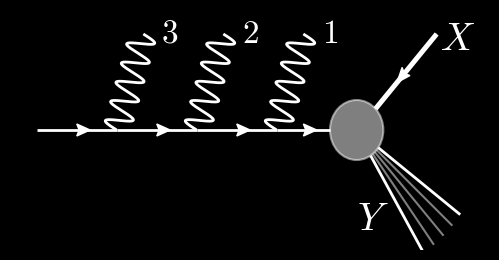

In [70]:
import numpy as np
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4

in1 = diagram.vertex(xy=(0.05, H/2), marker='', **style_params)
in1_1 = diagram.vertex(xy=(0.2, H/2), marker='', **style_params)
in1_2 = diagram.vertex(xy=(0.35, H/2), marker='', **style_params)
in1_3 = diagram.vertex(xy=(0.5, H/2), marker='', **style_params)

p_1 = diagram.vertex(xy=(0.25,H- 0.04), marker='', **style_params)
p_2 = diagram.vertex(xy=(0.4, H-0.04), marker='', **style_params)
p_3 = diagram.vertex(xy=(0.55, H- 0.04), marker='', **style_params)

center2 = diagram.vertex(xy=(0.6, 0.2),  marker='',**style_params)



out2 = diagram.vertex(xy=(0.8, H-0.04), marker='', **style_params)

#draw circle around center2 and fill with transparent main color 0.5 alpha, linecolor - alpha = 1

R = 0.05
C = center2.xy + (R,0)
ax.add_patch(plt.Circle(C, R, color=main_color, fill=True, alpha=0.5, linewidth=1.5))


center2_u = diagram.vertex(xy=C + (R*np.cos(np.pi/4),R*np.sin(np.pi/4)), marker='', **style_params)

angle_d = - np.pi/4*(1+0.3)
angle_u = -np.pi/4*(1-0.2)

center1_d = diagram.vertex(xy=C + (R*np.cos(angle_d),R*np.sin(angle_d)), marker='', **style_params)
center1_u = diagram.vertex(xy=C + (R*np.cos(angle_u),R*np.sin(angle_u)), marker='', **style_params)

N = 5
centres1_av = [diagram.vertex(xy=C + (R*np.cos(angle_d + i*(angle_u-angle_d)/(N-1)),R*np.sin(angle_d + i*(angle_u-angle_d)/(N-1))), marker='', **style_params) for i in range(1,N-1)]

R1 = 0.24
out1_u = diagram.vertex(xy=C + (R1*np.cos(angle_u),R1*np.sin(angle_u)), marker='', **style_params)
out1_d = diagram.vertex(xy=C + (R1*np.cos(angle_d),R1*np.sin(angle_d)), marker='', **style_params)

out1_av = [diagram.vertex(xy=C + (R1*np.cos(angle_d + i*(angle_u-angle_d)/(N-1)),R1*np.sin(angle_d + i*(angle_u-angle_d)/(N-1))), marker='', **style_params) for i in range(1,N-1)]

for (v1,v2) in zip(centres1_av, out1_av):
    diagram.line(v1,v2, **style_params,linewidth=1.5,alpha=0.5,arrow = False)

#diagram.line(center1,in2, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)

diagram.line(in1,in1_1, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(in1_1,in1_2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(in1_2,in1_3, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(in1_1,p_1, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(in1_2,p_2, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(in1_3,p_3, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)


diagram.line(in1_3, center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u, out1_u, **style_params,linewidth=2,arrow = False)
diagram.line(center1_d, out1_d, **style_params,linewidth=2,arrow = False)
#Line()
diagram.line( out2,center2_u, **style_params,linewidth=2,stroke  = 'double',arrow_param=arrow_params)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$X$", fontsize=28)
diagram.text(out1.xy[0]+0.08, out1.xy[1]+0.01, r"$Y$", fontsize=28)


diagram.text(p_1.xy[0]+0.05, p_1.xy[1], r"$3$", fontsize=24)
diagram.text(p_2.xy[0]+0.05, p_2.xy[1], r"$2$", fontsize=24)
diagram.text(p_3.xy[0]+0.05, p_3.xy[1], r"$1$", fontsize=24)

diagram.plot()

fig.savefig(f'../docs/DeepInelastic/Partons/images/PartonMultiple-{Theme.suff()}.svg',transparent=True)

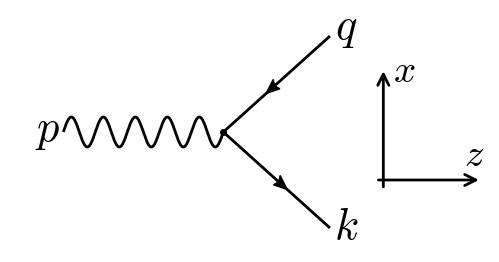

In [77]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, H/2), marker='', **style_params)

center1 = diagram.vertex(xy=(0.4, H/2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.6, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.6, H-0.04), marker='', **style_params)

diagram.line(in1,center1, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)

diagram.line(out2, center1,**style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, out1, **style_params,linewidth=2,arrow_param=arrow_params)



diagram.text(in1.xy[0]-0.03, in1.xy[1]+0.00, r"$p$", fontsize=32)
diagram.text(out1.xy[0]+0.03, out1.xy[1], r"$k$", fontsize=32)

diagram.text(out2.xy[0]+0.03, out2.xy[1]+0.01, r"$q$", fontsize=32)


from matplotlib.patches import FancyArrowPatch

Oxy_0 = (out1.xy+out2.xy)/2 + (0.1,-0.08)
arrow1 = FancyArrowPatch(posA=Oxy_0 - (0.03,0), 
                        posB=Oxy_0 + (0.2,0),
                        arrowstyle='->', 
                        mutation_scale=20,
                        linewidth=2,
                        shrinkA=8,
                        shrinkB=8)

arrow2 = FancyArrowPatch(posA=Oxy_0 - (0.0,0.03), 
                        posB=Oxy_0 + (0.0,0.2),
                        arrowstyle='->', 
                        mutation_scale=20,
                        linewidth=2,
                        shrinkA=8,
                        shrinkB=8)

ax.add_patch(arrow1)
ax.add_patch(arrow2)

diagram.text(Oxy_0[0]+0.17, Oxy_0[1]+0.04, r"$z$", fontsize=28)
diagram.text(Oxy_0[0]+0.04, Oxy_0[1]+0.18, r"$x$", fontsize=28)

diagram.plot()

fig.savefig(f'../docs/DeepInelastic/Partons/images/PhotonDecoupling-{Theme.suff()}.svg',transparent=True)